In [13]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")
tags = pd.read_csv("../data/tags.csv")

print(movies.shape)
print(ratings.shape)
print(tags.shape)

display(movies.head())
display(ratings.head())
display(tags.head())


(86537, 3)
(33832162, 4)
(2328315, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [21]:
print("Dubblettrader i movies:", movies.duplicated().sum())
print("Dubblettrader i ratings:", ratings.duplicated().sum())
print("Dubblettrader i tags:", tags.duplicated().sum())


Dubblettrader i movies: 0
Dubblettrader i ratings: 0
Dubblettrader i tags: 0


In [22]:
print("Dubbletter i movieId:", movies["movieId"].duplicated().sum())
print("Dubbletter i title:", movies["title"].duplicated().sum())


Dubbletter i movieId: 0
Dubbletter i title: 207


In [23]:
rating_key_dupes = ratings.duplicated(subset=["userId", "movieId"]).sum()
print("Dubbletter i ratings på userId + movieId:", rating_key_dupes)


Dubbletter i ratings på userId + movieId: 0


Verkar inte vara fler än en rating per film och userId. 

In [24]:
tag_dupes_user_movie = tags.duplicated(subset=["userId", "movieId"]).sum()
tag_dupes_full = tags.duplicated(subset=["userId", "movieId", "tag"]).sum()

print("Dubbletter i tags på userId + movieId:", tag_dupes_user_movie)
print("Dubbletter i tags på userId + movieId + tag:", tag_dupes_full)


Dubbletter i tags på userId + movieId: 1882104
Dubbletter i tags på userId + movieId + tag: 0


Verkar inte som att samma userId satt samma tag flera gånger på samma film. 

In [28]:
movie_tag_counts = (
    tags.groupby(["movieId", "tag"])
    .size()
    .reset_index(name="count")
    .merge(movies[["movieId", "title"]], on="movieId", how="left")
    .sort_values("count", ascending=False)
)

duplicate_movie_tags = movie_tag_counts[movie_tag_counts["count"] > 1]

print("Antal film-tag-kombinationer som förekommer mer än en gång:", len(duplicate_movie_tags))
display(duplicate_movie_tags.head(20))


Antal film-tag-kombinationer som förekommer mer än en gång: 180567


,movieId,tag,count,title
18978,260,sci-fi,1098,Star Wars: Episode IV - A New Hope (1977)
651619,79132,alternate reality,505,Inception (2010)
651814,79132,thought-provoking,501,Inception (2010)
188973,2959,twist ending,494,Fight Club (1999)
20558,296,Quentin Tarantino,483,Pulp Fiction (1994)
18134,260,Science Fiction,476,Star Wars: Episode IV - A New Hope (1977)
19034,260,space,469,Star Wars: Episode IV - A New Hope (1977)
18338,260,classic,456,Star Wars: Episode IV - A New Hope (1977)
165895,2571,sci-fi,442,"Matrix, The (1999)"
769452,109487,space,430,Interstellar (2014)


In [31]:
tags_copy = tags.copy()
tags_copy["tag_clean"] = tags_copy["tag"].astype(str).str.strip().str.lower()

movie_tag_counts_clean = (
    tags_copy.groupby(["movieId", "tag_clean"])
    .size()
    .reset_index(name="count")
    .merge(movies[["movieId", "title"]], on="movieId", how="left")
    .sort_values("count", ascending=False)
)

duplicate_movie_tags_clean = movie_tag_counts_clean[movie_tag_counts_clean["count"] > 1]

print("Antal film-tag-kombinationer > 1 efter normalisering:", len(duplicate_movie_tags_clean))
display(duplicate_movie_tags_clean.head(20))


Antal film-tag-kombinationer > 1 efter normalisering: 180515


,movieId,tag_clean,count,title
18499,260,sci-fi,1112,Star Wars: Episode IV - A New Hope (1977)
20696,296,quentin tarantino,561,Pulp Fiction (1994)
640024,79132,alternate reality,505,Inception (2010)
640268,79132,thought-provoking,501,Inception (2010)
184890,2959,twist ending,494,Fight Club (1999)
18508,260,science fiction,492,Star Wars: Episode IV - A New Hope (1977)
18565,260,space,486,Star Wars: Episode IV - A New Hope (1977)
17706,260,classic,476,Star Wars: Episode IV - A New Hope (1977)
162226,2571,sci-fi,442,"Matrix, The (1999)"
756070,109487,space,432,Interstellar (2014)


In [32]:
movie_tag_counts = (
    tags.groupby(["movieId", "tag"])
    .size()
    .reset_index(name="count")
)

repeated_tags_per_movie = (
    movie_tag_counts[movie_tag_counts["count"] > 1]
    .groupby("movieId")
    .agg(
        repeated_tag_pairs=("tag", "count"),
        total_repeated_uses=("count", "sum"),
        max_single_tag_repeat=("count", "max"),
    )
    .reset_index()
    .merge(movies[["movieId", "title"]], on="movieId", how="left")
    .sort_values(
        ["total_repeated_uses", "repeated_tag_pairs", "max_single_tag_repeat"],
        ascending=False
    )
)

display(repeated_tags_per_movie.head(20))


,movieId,repeated_tag_pairs,total_repeated_uses,max_single_tag_repeat,title
191,260,477,10184,1098,Star Wars: Episode IV - A New Hope (1977)
9267,79132,132,8812,505,Inception (2010)
214,296,333,8070,483,Pulp Fiction (1994)
11499,109487,153,7160,430,Interstellar (2014)
1741,2571,213,7098,442,"Matrix, The (1999)"
2012,2959,175,6934,494,Fight Club (1999)
230,318,359,6381,333,"Shawshank Redemption, The (1994)"
2880,4226,109,4411,397,Memento (2000)
4865,7361,131,4362,361,Eternal Sunshine of the Spotless Mind (2004)
260,356,234,4244,225,Forrest Gump (1994)


Det här betyder:  
  
- repeated_tag_pairs: hur många olika tags på filmen som förekommer mer än en gång
- total_repeated_uses: totalt antal förekomster av upprepade tags
- max_single_tag_repeat: den tag som upprepats flest gånger för just den filmen  
  
Skulle kunna använda mig av många av samma tag = verkligen stämmer med den tagen? Typ många "mindfuck", så är den verkligen det. Eller många quintin tarantino - viktigt? 

Hur många filmer finns? (movies.csv)   
- 86.537 (movieId, title, genres)  
Hur många ratings finns?  (ratings.csv)  
- 33.832.162 (userId, movieId, rating, timestamp)  
Hur många unika användare finns?
Vilka genres är vanligast?
Vilka filmer har flest ratings?
Hur ser rating-fördelningen ut?
Hur många tags finns per film?

,antal_filmer
genres,
Drama,33681
Comedy,22830
Thriller,11675
Romance,10172
Action,9563
Documentary,9283
Horror,8570
(no genres listed),7060
Crime,6917


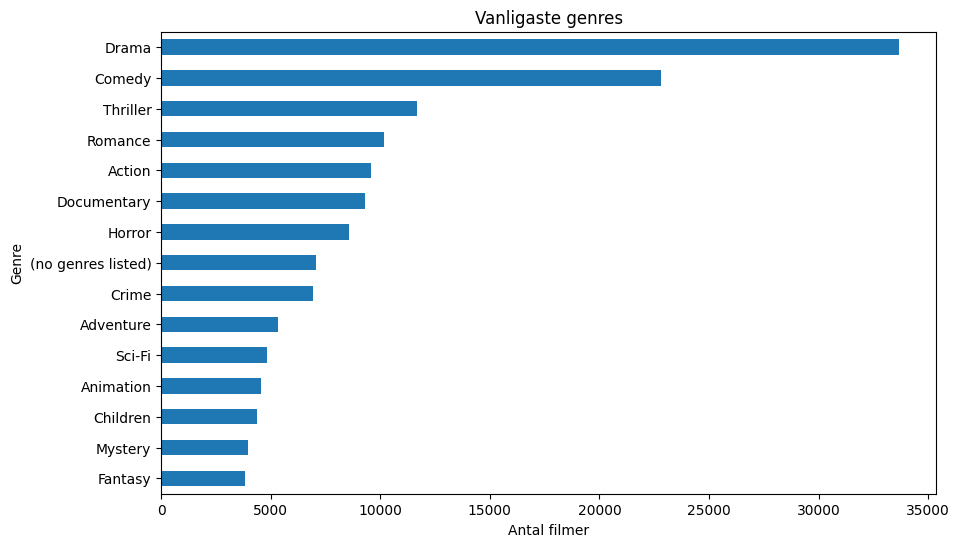

In [9]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

display(genre_counts.to_frame("antal_filmer").head(20))

plt.figure(figsize=(10, 6))
genre_counts.head(15).sort_values().plot(kind="barh")
plt.title("Vanligaste genres")
plt.xlabel("Antal filmer")
plt.ylabel("Genre")
plt.show()


,movieId,rating_count,title,genres
314,318,122296,"Shawshank Redemption, The (1994)",Crime|Drama
351,356,113581,Forrest Gump (1994),Comedy|Drama|Romance|War
292,296,108756,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2480,2571,107056,"Matrix, The (1999)",Action|Sci-Fi|Thriller
585,593,101802,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
257,260,97202,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
2867,2959,86207,Fight Club (1999),Action|Crime|Drama|Thriller
522,527,84232,Schindler's List (1993),Drama|War
475,480,83026,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
1166,1196,80200,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi


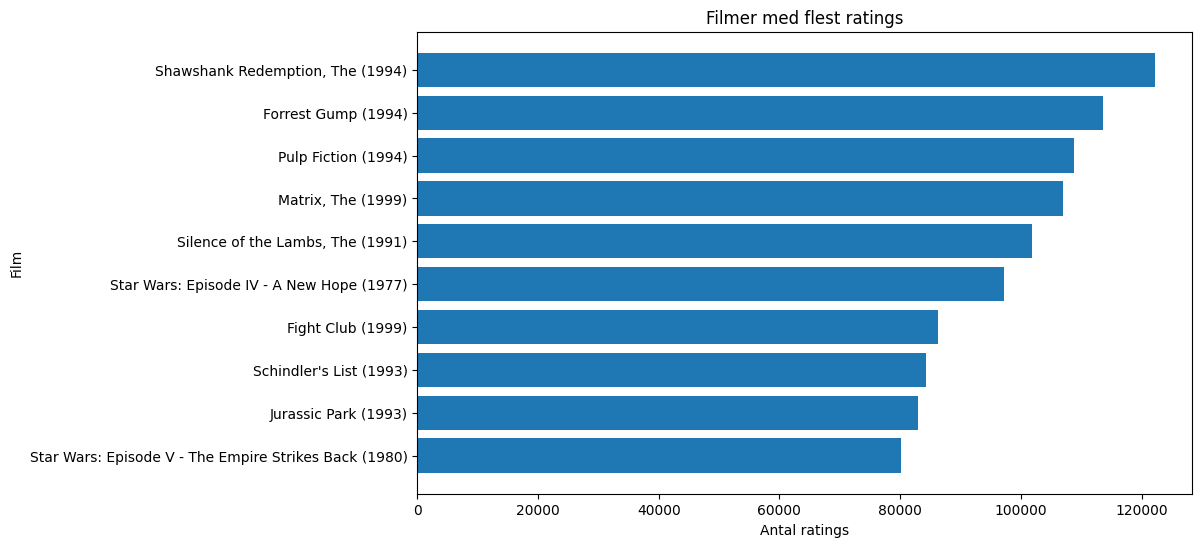

In [11]:
movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
    .merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")
    .sort_values("rating_count", ascending=False)
)

display(movie_rating_counts.head(20))
top_rated_movies = movie_rating_counts.head(10).sort_values("rating_count")

plt.figure(figsize=(10, 6))
plt.barh(top_rated_movies["title"], top_rated_movies["rating_count"])
plt.title("Filmer med flest ratings")
plt.xlabel("Antal ratings")
plt.ylabel("Film")
plt.show()



,antal
rating,
0.5,566306
1.0,1013645
1.5,562409
2.0,2146492
2.5,1760733
3.0,6400664
3.5,4465001
4.0,8835955
4.5,3123055


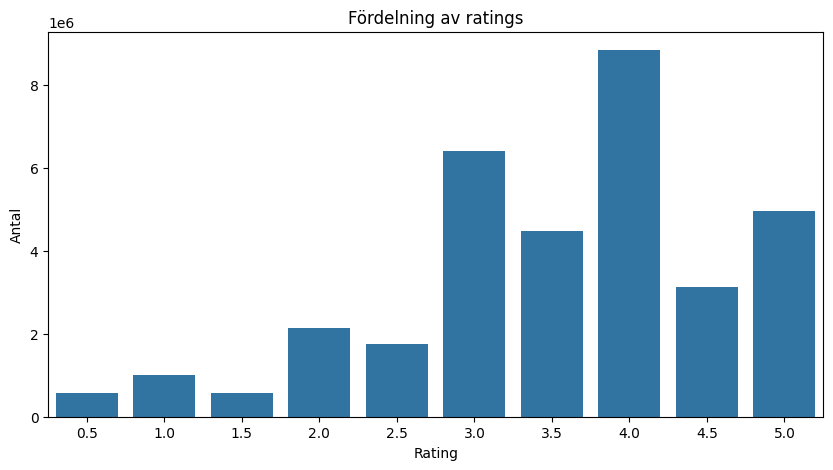

count    3.383216e+07
mean     3.542540e+00
std      1.063959e+00
min      5.000000e-01
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [14]:
rating_distribution = ratings["rating"].value_counts().sort_index()
display(rating_distribution.to_frame("antal"))

plt.figure(figsize=(10, 5))
sns.countplot(data=ratings, x="rating", order=sorted(ratings["rating"].unique()))
plt.title("Fördelning av ratings")
plt.xlabel("Rating")
plt.ylabel("Antal")
plt.show()

print(ratings["rating"].describe())


Ojämn fördelning av ratings? Ovanligt med låg rating. 

In [15]:
tags_per_movie = (
    tags.groupby("movieId")
    .size()
    .reset_index(name="tag_count")
    .merge(movies[["movieId", "title"]], on="movieId", how="left")
    .sort_values("tag_count", ascending=False)
)

display(tags_per_movie.head(20))
print(tags_per_movie["tag_count"].describe())


,movieId,tag_count,title
248,260,11152,Star Wars: Episode IV - A New Hope (1977)
14323,79132,8978,Inception (2010)
281,296,8753,Pulp Fiction (1994)
2350,2571,7593,"Matrix, The (1999)"
2723,2959,7459,Fight Club (1999)
19894,109487,7331,Interstellar (2014)
302,318,6839,"Shawshank Redemption, The (1994)"
339,356,4880,Forrest Gump (1994)
6940,7361,4680,Eternal Sunshine of the Spotless Mind (2004)
3931,4226,4675,Memento (2000)


count    53452.000000
mean        43.558988
std        197.466261
min          1.000000
25%          2.000000
50%          6.000000
75%         18.000000
max      11152.000000
Name: tag_count, dtype: float64


Vad innebär det egentligen att ha många tags? Vem sätter tagsen? Beror det på innehåll? Beror det på bra kvalitet/handling/skådespelare eller antal skådespelare/platser/osv? 

Antal tags per film, inklusive filmer utan tags

In [18]:
all_movies_tag_counts = (
    movies[["movieId", "title"]]
    .merge(tags_per_movie, on="movieId", how="left")
)

all_movies_tag_counts["tag_count"] = all_movies_tag_counts["tag_count"].fillna(0)

print("Median antal tags per film (alla filmer, även utan tags):")
print(all_movies_tag_counts["tag_count"].median())


Median antal tags per film (alla filmer, även utan tags):
2.0


Antal tags per film, bara för filmer som faktiskt har tags

In [19]:
tags_per_movie = (
    tags.groupby("movieId")
    .size()
    .reset_index(name="tag_count")
)

print("Median antal tags per film (bara filmer med tags):")
print(tags_per_movie["tag_count"].median())


Median antal tags per film (bara filmer med tags):
6.0


In [20]:
display(all_movies_tag_counts["tag_count"].describe())


count    86537.000000
mean        26.905428
std        156.630058
min          0.000000
25%          0.000000
50%          2.000000
75%          8.000000
max      11152.000000
Name: tag_count, dtype: float64

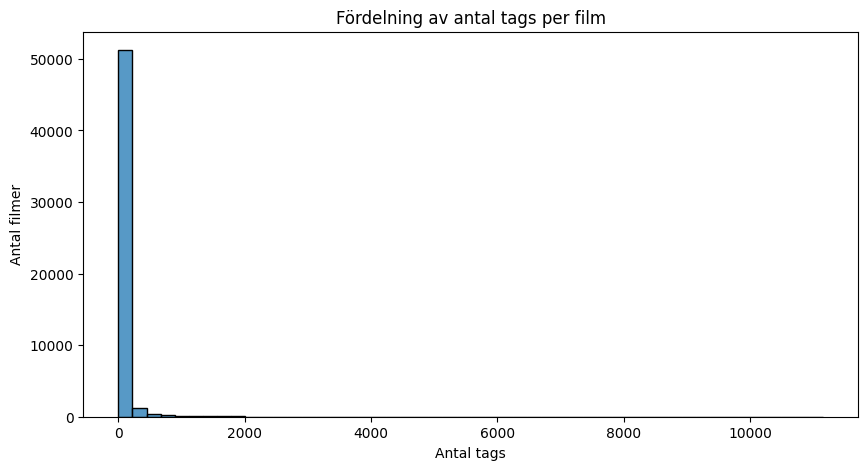

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(tags_per_movie["tag_count"], bins=50)
plt.title("Fördelning av antal tags per film")
plt.xlabel("Antal tags")
plt.ylabel("Antal filmer")
plt.show()


Det verkar bara vara ett fåtal filmer som har många tags. 

In [17]:
movies_with_tags = tags["movieId"].nunique()
movies_without_tags = movies["movieId"].nunique() - movies_with_tags

print(f"Filmer med minst en tag: {movies_with_tags}")
print(f"Filmer utan tags: {movies_without_tags}")


Filmer med minst en tag: 53452
Filmer utan tags: 33085


33.085 filmer av 86537  har inga tags alls. 53.452 har minst en tag. 